In [1]:
import numpy as np
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from rdkit.Chem.Descriptors import MolLogP
from sklearn.metrics import confusion_matrix,accuracy_score,f1_score
from rdkit.Chem.AllChem import GetMorganFingerprintAsBitVect
from rdkit.Chem import Descriptors
from rdkit.Chem import PandasTools
from rdkit.DataStructs import ExplicitBitVect

import sys
import multiprocessing
from standardiser import break_bonds, neutralise, rules, unsalt
from standardiser.utils import StandardiseException, sanity_check
def warn(*args, **kwargs):
    pass 
import warnings
warnings.filterwarnings("ignore")
warnings.warn = warn
from rdkit.Chem import AllChem as Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
import sys
from sklearn.metrics import cohen_kappa_score
import csv
from rdkit.Chem import MACCSkeys
from sklearn.model_selection import ShuffleSplit
import _pickle as cPickle
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.model_selection import StratifiedShuffleSplit    
import bz2
from glob import glob
import _pickle as cPickle
import pickle





In [2]:
# Function to read SDF file into DataFrame
def load_sdf_to_df(filename):
    suppl = Chem.SDMolSupplier(filename)
    rows = []
    for mol in suppl:
        if mol is not None:
            row = {prop: mol.GetProp(prop) for prop in mol.GetPropNames()}
            row['SMILES'] = Chem.MolToSmiles(mol)
            rows.append(row)
    return pd.DataFrame(rows)

# Load the  test sets from SDF files
test_df = load_sdf_to_df(r'D:\Riset QSAR - TTX\Machine Learning (Done)\Skin Sensization\Dataset\test_set_skin_sensitization_features_rdkitcdk.sdf')

# Convert strings back to lists of integers
def string_to_list(bit_string):
    if isinstance(bit_string, str):
        return list(map(int, bit_string.strip('[]').split(', ')))
    else:
        return bit_string


test_df['Morgan_Descriptors'] = test_df['Morgan_Descriptors'].apply(string_to_list)
test_df['MACCS_Descriptors'] = test_df['MACCS_Descriptors'].apply(string_to_list)

def string_to_list(descriptor):
    if isinstance(descriptor, str):
        return list(map(float, descriptor.strip('[]').split(',')))
    return descriptor

# Apply the function to the 'Modred_Descriptor' column
test_df['Modred_Descriptor'] = test_df['Modred_Descriptor'].apply(string_to_list)

# Convert 'Modred_Descriptor' column to a NumPy array
data_modred_test = np.array(test_df['Modred_Descriptor'].tolist())


print("Test DataFrame:")
print(test_df.head())


Test DataFrame:
                                       Compound name Outcome LLNA class RowID  \
0            2-cyclohexylsulfanylisoindole-1,3-dione       1              288   
1                             1,2-Diaminocyclohexane       1     Strong   196   
2  (2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...       1              179   
3                              Trimellitic anhydride       1   Moderate    52   
4          2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol       1              286   

                                  Morgan_Descriptors  \
0  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
2  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
3  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
4  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...   

                                   MACCS_Descriptors  \
0  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1  [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [3]:
data_modred_test.shape

(199, 545)

In [4]:
test_df.keys()

Index(['Compound name', 'Outcome', 'LLNA class', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'ID', 'SMILES',
       'Molecular Weight', 'logP', 'LabuteASA', 'TPSA', 'AMW',
       'NumLipinskiHBA', 'NumLipinskiHBD', 'NumRotatableBonds', 'NumHBD',
       'NumHBA', 'NumAmideBonds', 'NumHeteroAtoms', 'NumAtoms', 'NumRings',
       'NumAromaticRings', 'NumSaturatedRings', 'NumAliphaticRings',
       'NumAromaticHeterocycles', 'NumSaturatedHeterocycles',
       'NumAliphaticHeterocycles', 'NumAromaticCarbocycles',
       'NumSaturatedCarbocycles', 'NumAliphaticCarbocycles', 'FractionCSP3',
       'Chi0v', 'Chi1v', 'Chi2v', 'Chi3v', 'Chi4v', 'Chi1n', 'Chi2n', 'Chi3n',
       'Chi4n', 'HallKierAlpha', 'kappa1', 'kappa2', 'kappa3', 'ALogP',
       'ALogP2', 'AMR', 'MLogP', 'nAtomP', 'naAromAtom', 'bpol', 'nB', 'ECCEN',
       'fragC', 'nHBAcc', 'nHBDon', 'nAtomLAC', 'nAtomLC', 'PetitjeanNumber',
       'nRotB', 'LipinskiFailures', 'TopoPSA', 'VAdjMat', 'XLogP

In [5]:
test_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,"2-cyclohexylsulfanylisoindole-1,3-dione",1,,288,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.0042457655443273136, 0.11801186580348445, ...",288,O=C1c2ccccc2C(=O)N1SC1CCCCC1,261.08234972,...,0.0,0.0,0.0,0.4444444444444444,2.0,0.0,62.68000000000001,5.321928094887363,3.5490000000000004,0.4285714285714285
1,"1,2-Diaminocyclohexane",1,Strong,196,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9713079998634846, -0.8690458206165751, -0....",196,NC1CCCCC1N,114.11569844799999,...,2.0,0.0,0.0,0.25,0.0,0.0,52.04,4.0,-0.046,1.0
2,"(2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...",1,,179,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5610715773768501, 0.7132257856329035, 0.558...",179,O=C(OOC(=O)c1ccc(Cl)cc1Cl)c1ccc(Cl)cc1Cl,377.902019392,...,0.0,0.0,6.0,0.4615384615384615,5.0,1.0,52.6,5.523561956057013,5.808000000000001,0.0
3,Trimellitic anhydride,1,Moderate,52,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.35917252633357244, 0.3550611526996406, 0.45...",52,O=C(O)c1ccc2c(c1)C(=O)OC2=O,192.005873228,...,1.0,0.0,3.0,0.4285714285714285,1.0,0.0,80.66999999999999,4.906890595608519,1.138,0.0
4,2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol,1,,286,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.27280572361002964, -0.5367882135736023, -0...",286,OCCOCC#CCOCCO,174.089208928,...,2.0,4.0,12.0,0.4545454545454545,6.0,0.0,58.92,4.459431618637298,-1.2600000000000002,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Cyclopentanepropanol,0,Non-sensitizer,846,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9158713112719405, -0.886533063092521, -0.8...",846,OCCCC1CCCC1,128.120115132,...,1.0,3.0,4.0,0.5,3.0,0.0,20.23,4.169925001442312,2.7259999999999995,1.0
195,Indanthrene blue,0,,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.7340024034038648, 2.2378542592764865, 2.348...",877,O=c1c2ccccc2c(=O)c2c1ccc1[nH]c3c(ccc4c(=O)c5cc...,442.095356928,...,2.0,0.0,0.0,0.4666666666666667,0.0,1.0,92.34,6.321928094887363,5.354000000000001,0.0
196,"3'-[(2z)-[1-(3,4-dimethylphenyl)-1,5-dihydro-3...",0,Non-sensitizer,746,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5011683113193799, 1.853134924805676, 1.6670...",746,Cc1ccc(-n2[nH]c(C)c(/N=N/c3cccc(-c4cccc(C(=O)O...,442.1641051839999,...,3.0,0.0,3.0,0.4705882352941176,5.0,1.0,120.04,6.169925001442312,6.4110000000000005,0.12
197,"(3R,6Rr)-3-(2,3-dihydro-1H-inden-2-yl)-1-[(1R)...",0,Non-sensitizer,562,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 1.701578823347478, 1.5655...",562,CCC(C)C1C(=O)NC(C2Cc3ccccc3C2)C(=O)N1C(C(=O)N1...,494.25292018799996,...,1.0,4.0,4.0,0.4615384615384615,7.0,0.0,104.98,6.321928094887363,1.5930000000000002,0.5555555555555556


In [6]:
test_df = test_df.rename(columns={'Outcome': 'Outcome'})

Classes                          :  ['0' '1']
Number of cpds in each class     :  [ 99 100]
Total number of cpds             :  199


{'1': 0, '0': 1}

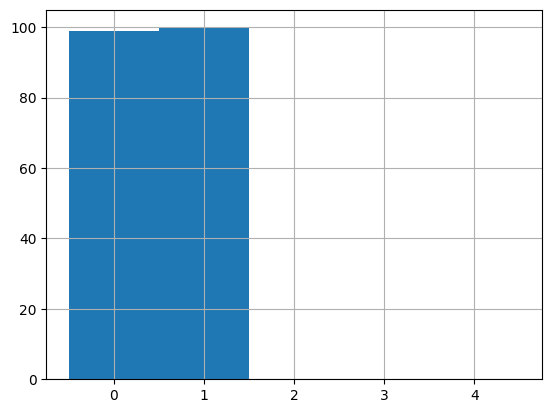

In [7]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


outcomes=(np.unique(test_df['Outcome']))
le.fit(list(set(outcomes)))
y = le.transform( test_df['Outcome'] )



print ("Classes                          : ",(outcomes))
print ("Number of cpds in each class     : ",np.unique([len(y[y==smi]) for smi in y]))
print ("Total number of cpds             : ",len(y))

S = test_df['Outcome']
info = {}
for i,cls in enumerate(S.unique()):
    info.update({cls:i})
    S = S.replace(cls,i)

#graph
ax = S.hist(bins=np.arange(-0.5,5))
ax.set_xticks(range(0,5))
info

In [8]:
test_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nHBDon,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3
0,"2-cyclohexylsulfanylisoindole-1,3-dione",1,,288,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.0042457655443273136, 0.11801186580348445, ...",288,O=C1c2ccccc2C(=O)N1SC1CCCCC1,261.08234972,...,0.0,0.0,0.0,0.4444444444444444,2.0,0.0,62.68000000000001,5.321928094887363,3.5490000000000004,0.4285714285714285
1,"1,2-Diaminocyclohexane",1,Strong,196,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9713079998634846, -0.8690458206165751, -0....",196,NC1CCCCC1N,114.11569844799999,...,2.0,0.0,0.0,0.25,0.0,0.0,52.04,4.0,-0.046,1.0
2,"(2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...",1,,179,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5610715773768501, 0.7132257856329035, 0.558...",179,O=C(OOC(=O)c1ccc(Cl)cc1Cl)c1ccc(Cl)cc1Cl,377.902019392,...,0.0,0.0,6.0,0.4615384615384615,5.0,1.0,52.6,5.523561956057013,5.808000000000001,0.0
3,Trimellitic anhydride,1,Moderate,52,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.35917252633357244, 0.3550611526996406, 0.45...",52,O=C(O)c1ccc2c(c1)C(=O)OC2=O,192.005873228,...,1.0,0.0,3.0,0.4285714285714285,1.0,0.0,80.66999999999999,4.906890595608519,1.138,0.0
4,2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol,1,,286,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.27280572361002964, -0.5367882135736023, -0...",286,OCCOCC#CCOCCO,174.089208928,...,2.0,4.0,12.0,0.4545454545454545,6.0,0.0,58.92,4.459431618637298,-1.2600000000000002,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Cyclopentanepropanol,0,Non-sensitizer,846,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9158713112719405, -0.886533063092521, -0.8...",846,OCCCC1CCCC1,128.120115132,...,1.0,3.0,4.0,0.5,3.0,0.0,20.23,4.169925001442312,2.7259999999999995,1.0
195,Indanthrene blue,0,,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.7340024034038648, 2.2378542592764865, 2.348...",877,O=c1c2ccccc2c(=O)c2c1ccc1[nH]c3c(ccc4c(=O)c5cc...,442.095356928,...,2.0,0.0,0.0,0.4666666666666667,0.0,1.0,92.34,6.321928094887363,5.354000000000001,0.0
196,"3'-[(2z)-[1-(3,4-dimethylphenyl)-1,5-dihydro-3...",0,Non-sensitizer,746,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5011683113193799, 1.853134924805676, 1.6670...",746,Cc1ccc(-n2[nH]c(C)c(/N=N/c3cccc(-c4cccc(C(=O)O...,442.1641051839999,...,3.0,0.0,3.0,0.4705882352941176,5.0,1.0,120.04,6.169925001442312,6.4110000000000005,0.12
197,"(3R,6Rr)-3-(2,3-dihydro-1H-inden-2-yl)-1-[(1R)...",0,Non-sensitizer,562,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 1.701578823347478, 1.5655...",562,CCC(C)C1C(=O)NC(C2Cc3ccccc3C2)C(=O)N1C(C(=O)N1...,494.25292018799996,...,1.0,4.0,4.0,0.4615384615384615,7.0,0.0,104.98,6.321928094887363,1.5930000000000002,0.5555555555555556


In [9]:
x_rdkitcdk = test_df.drop(columns=['Compound name', 'Outcome', 'LLNA class', 'RowID', 'Morgan_Descriptors',
       'MACCS_Descriptors', 'Modred_Descriptor', 'ID', 'SMILES','Molecular Weight', 'logP'])

In [10]:
print(x_rdkitcdk)

              LabuteASA                TPSA                 AMW  \
0    110.68064313389601               37.38  261.34599999999995   
1     50.23791184030878               52.04  114.19200000000001   
2    144.91087643672049                52.6   380.0100000000001   
3     77.91274359099175   80.66999999999999  192.12599999999995   
4     72.10862918387086               58.92  174.19599999999997   
..                  ...                 ...                 ...   
194    57.0822484272726               20.23             128.215   
195  188.60677467197624   99.85999999999999   442.4300000000002   
196    189.027977201205  120.03999999999999  442.47500000000025   
197  210.72158022278856              104.98   494.5920000000003   
198   68.80604609307427               17.07             152.237   

    NumLipinskiHBA NumLipinskiHBD NumRotatableBonds NumHBD NumHBA  \
0                3              0                 2      0      3   
1                2              2                 0      

In [11]:
x_rdkitcdk  = x_rdkitcdk.apply(lambda row: row.values, axis=1).tolist()

# Add the new column 'rdkit_cdk' to test_df
test_df['rdkit_cdk'] = x_rdkitcdk 

# Display the updated DataFrame
print(test_df)

                                         Compound name Outcome  \
0              2-cyclohexylsulfanylisoindole-1,3-dione       1   
1                               1,2-Diaminocyclohexane       1   
2    (2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...       1   
3                                Trimellitic anhydride       1   
4            2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol       1   
..                                                 ...     ...   
194                               Cyclopentanepropanol       0   
195                                   Indanthrene blue       0   
196  3'-[(2z)-[1-(3,4-dimethylphenyl)-1,5-dihydro-3...       0   
197  (3R,6Rr)-3-(2,3-dihydro-1H-inden-2-yl)-1-[(1R)...       0   
198                                             Citral       1   

         LLNA class RowID                                 Morgan_Descriptors  \
0                     288  [0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...   
1            Strong   196  [0, 0, 0, 0, 1, 0, 0

In [12]:
y_test= np.int32((S))
x_test_morgan = np.array(list(test_df['Morgan_Descriptors']))
x_test_macckeys = np.array(list(test_df['MACCS_Descriptors']))
x_test_modred= np.array(list(test_df['Modred_Descriptor']))
x_test_rdkit_cdk = np.array(list(test_df['rdkit_cdk']))

In [13]:
x_test_rdkit_cdk

array([['110.68064313389601', '37.38', '261.34599999999995', ...,
        '5.321928094887363', '3.5490000000000004', '0.4285714285714285'],
       ['50.23791184030878', '52.04', '114.19200000000001', ..., '4.0',
        '-0.046', '1.0'],
       ['144.91087643672049', '52.6', '380.0100000000001', ...,
        '5.523561956057013', '5.808000000000001', '0.0'],
       ...,
       ['189.027977201205', '120.03999999999999', '442.47500000000025',
        ..., '6.169925001442312', '6.4110000000000005', '0.12'],
       ['210.72158022278856', '104.98', '494.5920000000003', ...,
        '6.321928094887363', '1.5930000000000002', '0.5555555555555556'],
       ['68.80604609307427', '17.07', '152.237', ...,
        '4.321928094887363', '2.701', '0.5']], dtype=object)

In [14]:
import joblib
import numpy as np
import ast

# Function to ensure data is a NumPy array
def ensure_numpy_array(data):
    if isinstance(data, np.ndarray):
        return data
    elif isinstance(data, list):
        return np.array(data)
    elif hasattr(data, 'to_numpy'):  # For Pandas DataFrame
        return data.to_numpy()
    else:
        raise ValueError("Data format not recognized. Ensure it is a list, numpy array, or pandas DataFrame.")

# Function to check if all elements are numerical
def check_numerical(data):
    if not np.issubdtype(data.dtype, np.number):
        raise ValueError("Data contains non-numerical values. Ensure all elements are numerical.")

# Function to convert string representations of lists to numerical arrays
def parse_string_lists(data):
    parsed_data = []
    for item in data:
        if isinstance(item, str):
            try:
                parsed_item = ast.literal_eval(item)
                parsed_data.append(parsed_item)
            except (ValueError, SyntaxError):
                raise ValueError(f"Cannot parse value '{item}'")
        else:
            parsed_data.append(item)
    return np.array(parsed_data)

# Ensure training data is properly formatted
x_test_morgan = ensure_numpy_array(x_test_morgan)
x_test_macckeys = ensure_numpy_array(x_test_macckeys)
x_test_modred = ensure_numpy_array(x_test_modred)

check_numerical(x_test_morgan)
check_numerical(x_test_macckeys)

# Parse and convert string lists in x_test_modred
x_test_modred = parse_string_lists(x_test_modred)
check_numerical(x_test_modred)





In [15]:
x_test = np.concatenate((x_test_morgan, x_test_macckeys, x_test_modred), axis=1)

In [16]:
#load model - all included
import joblib

# Base paths
fingerprint_path = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Skin Sensization\Model\Descriptor"
phys_path        = r"D:\Riset QSAR - TTX\Machine Learning (Done)\Skin Sensization\Model\Physiochemical"

# descriptor
rf_morgan   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_RF_morgan.pkl")  
rf_maccskey    = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_RF_maccskey.pkl")
rf_modred   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_RF_modred.pkl")

svm_morgan  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_SVM_morgan.pkl")  
svm_maccskey   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_SVM_maccskey.pkl")
svm_modred  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_SVM_modred.pkl")

xgb_morgan  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_XGB_morgan.pkl")  
xgb_maccskey   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_XGB_maccskey.pkl")
xgb_modred  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_XGB_modred.pkl")

nn_morgan   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_NN_morgan.pkl")  
nn_maccskey    = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_NN_maccskey.pkl")
nn_modred   = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_NN_modred.pkl")

lgbm_morgan = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_LGBM_morgan.pkl")  
lgbm_maccskey  = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_LGBM_maccskey.pkl")
lgbm_modred = joblib.load(fr"{fingerprint_path}\Model_Skin_sens_LGBM_modred.pkl")

# physiochemical
rf_phys   = joblib.load(fr"{phys_path}\Model_Skin_sens_RF_rdkit_cdk.pkl")
svm_phys  = joblib.load(fr"{phys_path}\Model_Skin_sens_SVM_rdkit_cdk.pkl")
xgb_phys  = joblib.load(fr"{phys_path}\Model_Skin_sens_XGB_rdkit_cdk.pkl")
nn_phys   = joblib.load(fr"{phys_path}\Model_Skin_sens_NN_rdkit_cdk.pkl")
lgbm_phys = joblib.load(fr"{phys_path}\Model_Skin_sens_LGBM_rdkit_cdk.pkl")


In [17]:
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score, classification_report
y_true = test_df['Outcome'].astype(int)  # Ensure it's of integer type, suitable for metrics calculation


In [18]:
test_df

,Compound name,Outcome,LLNA class,RowID,Morgan_Descriptors,MACCS_Descriptors,Modred_Descriptor,ID,SMILES,Molecular Weight,...,nAtomLAC,nAtomLC,PetitjeanNumber,nRotB,LipinskiFailures,TopoPSA,VAdjMat,XLogP,Fsp3,rdkit_cdk
0,"2-cyclohexylsulfanylisoindole-1,3-dione",1,,288,"[0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.0042457655443273136, 0.11801186580348445, ...",288,O=C1c2ccccc2C(=O)N1SC1CCCCC1,261.08234972,...,0.0,0.0,0.4444444444444444,2.0,0.0,62.68000000000001,5.321928094887363,3.5490000000000004,0.4285714285714285,"[110.68064313389601, 37.38, 261.34599999999995..."
1,"1,2-Diaminocyclohexane",1,Strong,196,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9713079998634846, -0.8690458206165751, -0....",196,NC1CCCCC1N,114.11569844799999,...,0.0,0.0,0.25,0.0,0.0,52.04,4.0,-0.046,1.0,"[50.23791184030878, 52.04, 114.19200000000001,..."
2,"(2,4-dichlorobenzoyl) 2,4-dichlorobenzenecarbo...",1,,179,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.5610715773768501, 0.7132257856329035, 0.558...",179,O=C(OOC(=O)c1ccc(Cl)cc1Cl)c1ccc(Cl)cc1Cl,377.902019392,...,0.0,6.0,0.4615384615384615,5.0,1.0,52.6,5.523561956057013,5.808000000000001,0.0,"[144.91087643672049, 52.6, 380.0100000000001, ..."
3,Trimellitic anhydride,1,Moderate,52,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0.35917252633357244, 0.3550611526996406, 0.45...",52,O=C(O)c1ccc2c(c1)C(=O)OC2=O,192.005873228,...,0.0,3.0,0.4285714285714285,1.0,0.0,80.66999999999999,4.906890595608519,1.138,0.0,"[77.91274359099175, 80.66999999999999, 192.125..."
4,2-[4-(2-hydroxyethoxy)but-2-ynoxy]ethanol,1,,286,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.27280572361002964, -0.5367882135736023, -0...",286,OCCOCC#CCOCCO,174.089208928,...,4.0,12.0,0.4545454545454545,6.0,0.0,58.92,4.459431618637298,-1.2600000000000002,0.75,"[72.10862918387086, 58.92, 174.19599999999997,..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
194,Cyclopentanepropanol,0,Non-sensitizer,846,"[0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[-0.9158713112719405, -0.886533063092521, -0.8...",846,OCCCC1CCCC1,128.120115132,...,3.0,4.0,0.5,3.0,0.0,20.23,4.169925001442312,2.7259999999999995,1.0,"[57.0822484272726, 20.23, 128.215, 1, 1, 3, 1,..."
195,Indanthrene blue,0,,877,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.7340024034038648, 2.2378542592764865, 2.348...",877,O=c1c2ccccc2c(=O)c2c1ccc1[nH]c3c(ccc4c(=O)c5cc...,442.095356928,...,0.0,0.0,0.4666666666666667,0.0,1.0,92.34,6.321928094887363,5.354000000000001,0.0,"[188.60677467197624, 99.85999999999999, 442.43..."
196,"3'-[(2z)-[1-(3,4-dimethylphenyl)-1,5-dihydro-3...",0,Non-sensitizer,746,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5011683113193799, 1.853134924805676, 1.6670...",746,Cc1ccc(-n2[nH]c(C)c(/N=N/c3cccc(-c4cccc(C(=O)O...,442.1641051839999,...,0.0,3.0,0.4705882352941176,5.0,1.0,120.04,6.169925001442312,6.4110000000000005,0.12,"[189.027977201205, 120.03999999999999, 442.475..."
197,"(3R,6Rr)-3-(2,3-dihydro-1H-inden-2-yl)-1-[(1R)...",0,Non-sensitizer,562,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[1.5344303244743063, 1.701578823347478, 1.5655...",562,CCC(C)C1C(=O)NC(C2Cc3ccccc3C2)C(=O)N1C(C(=O)N1...,494.25292018799996,...,4.0,4.0,0.4615384615384615,7.0,0.0,104.98,6.321928094887363,1.5930000000000002,0.5555555555555556,"[210.72158022278856, 104.98, 494.5920000000003..."


In [19]:
#physiochemical consensus here - only phys
#descriptor not yet included here!
# Predict with all phys models (RF, SVM, XGB, NN, LGBM)


#PHYSICOCHEMICAL CONSENSUS
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, f1_score

def predict_with_phys_models(test_df):
    # Get probabilities from each phys model
    rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
    lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

    # Calculate mean probability across all phys models
    consensus_physicochemical_probs = np.mean(
        [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
        axis=0
    )

    # Convert mean probabilities to final class predictions (threshold = 0.5)
    final_predictions = (consensus_physicochemical_probs > 0.5).astype(int)

    return final_predictions, consensus_physicochemical_probs

# Run prediction
final_predictions, consensus_physicochemical_probs = predict_with_phys_models(test_df)
test_df['Phys_Predictions'] = final_predictions
test_df['Phys_Consensus_Probabilities'] = consensus_physicochemical_probs

y_true = test_df['Outcome'].astype(int)

# Evaluate performance
conf_matrix = confusion_matrix(y_true, final_predictions)
print("Confusion Matrix:")
print(conf_matrix)

accuracy = accuracy_score(y_true, final_predictions)
print("Accuracy:", accuracy)

auc_score = roc_auc_score(y_true, consensus_physicochemical_probs)
print("AUC Score:", auc_score)

f1 = f1_score(y_true, final_predictions, average='binary')
print("F1 Score:", f1)

tn, fp, fn, tp = conf_matrix.ravel()
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

# Correct Classification Rate (CCR)
ccr = (sensitivity + specificity) / 2
print("CCR (Correct Classification Rate):", ccr)

# Positive Predictive Value (PPV)
ppv = tp / (tp + fp) if (tp + fp) > 0 else 0
print("PPV (Positive Predictive Value):", ppv)

# Negative Predictive Value (NPV)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
print("NPV (Negative Predictive Value):", npv)


Confusion Matrix:
[[70 30]
 [32 67]]
Accuracy: 0.6884422110552764
AUC Score: 0.7429292929292929
F1 Score: 0.6836734693877551
Sensitivity: 0.6767676767676768
Specificity: 0.7
CCR (Correct Classification Rate): 0.6883838383838383
PPV (Positive Predictive Value): 0.6907216494845361
NPV (Negative Predictive Value): 0.6862745098039216


In [20]:
# RF
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_rf_from_pkl(test_df, rf_morgan, rf_maccskey, rf_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :rf_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :rf_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :rf_modred.n_features_in_]

    return {
        "Morgan":   rf_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": rf_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   rf_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_rf = predict_probabilities_rf_from_pkl(
    test_df,
    rf_morgan,
    rf_maccskey,
    rf_modred
)

for model_name, y_prob in probs_rf.items():
    print(f"\n{model_name} RF Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_rf = consensus_probability(probs_rf)
consensus_metrics_rf = evaluate_model(y_true, consensus_probs_rf)

print("\nCONSENSUS RF (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_rf.items():
    print(f"{k}: {v}")



Morgan RF Performance
Confusion Matrix: [[56 44]
 [34 65]]
Accuracy: 0.6080402010050251
AUC: 0.6544444444444444
F1 Score: 0.625
Sensitivity: 0.6565656565656566
Specificity: 0.56
CCR: 0.6082828282828283
PPV (Precision): 0.5963302752293578
NPV: 0.6222222222222222

MACCSkey RF Performance
Confusion Matrix: [[72 28]
 [36 63]]
Accuracy: 0.678391959798995
AUC: 0.7275757575757577
F1 Score: 0.6631578947368421
Sensitivity: 0.6363636363636364
Specificity: 0.72
CCR: 0.6781818181818182
PPV (Precision): 0.6923076923076923
NPV: 0.6666666666666666

Modred RF Performance
Confusion Matrix: [[71 29]
 [30 69]]
Accuracy: 0.7035175879396985
AUC: 0.7752525252525252
F1 Score: 0.700507614213198
Sensitivity: 0.696969696969697
Specificity: 0.71
CCR: 0.7034848484848485
PPV (Precision): 0.7040816326530612
NPV: 0.7029702970297029

CONSENSUS RF (Morgan + MACCSkey + Modred)
Confusion Matrix: [[70 30]
 [33 66]]
Accuracy: 0.6834170854271356
AUC: 0.7535353535353535
F1 Score: 0.676923076923077
Sensitivity: 0.6666666666

In [21]:
# SVM
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, svm_morgan, svm_maccskey, svm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :svm_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :svm_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :svm_modred.n_features_in_]

    return {
        "Morgan":   svm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": svm_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   svm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_svm = predict_probabilities_from_pkl(
    test_df,
    svm_morgan,
    svm_maccskey,
    svm_modred
)

for model_name, y_prob in probs_svm.items():
    print(f"\n{model_name} SVM Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_svm = consensus_probability(probs_svm)
consensus_metrics_svm = evaluate_model(y_true, consensus_probs_svm)

print("\nCONSENSUS SVM (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_svm.items():
    print(f"{k}: {v}")



Morgan SVM Performance
Confusion Matrix: [[65 35]
 [39 60]]
Accuracy: 0.628140703517588
AUC: 0.7168686868686869
F1 Score: 0.6185567010309279
Sensitivity (Recall+): 0.6060606060606061
Specificity (Recall-): 0.65
CCR: 0.628030303030303
PPV (Precision): 0.631578947368421
NPV: 0.625

MACCSkey SVM Performance
Confusion Matrix: [[65 35]
 [39 60]]
Accuracy: 0.628140703517588
AUC: 0.719090909090909
F1 Score: 0.6185567010309279
Sensitivity (Recall+): 0.6060606060606061
Specificity (Recall-): 0.65
CCR: 0.628030303030303
PPV (Precision): 0.631578947368421
NPV: 0.625

Modred SVM Performance
Confusion Matrix: [[67 33]
 [29 70]]
Accuracy: 0.6884422110552764
AUC: 0.76010101010101
F1 Score: 0.693069306930693
Sensitivity (Recall+): 0.7070707070707071
Specificity (Recall-): 0.67
CCR: 0.6885353535353536
PPV (Precision): 0.6796116504854369
NPV: 0.6979166666666666

CONSENSUS SVM (Morgan + MACCSkey + Modred)
Confusion Matrix: [[67 33]
 [34 65]]
Accuracy: 0.6633165829145728
AUC: 0.7587878787878788
F1 Score:

In [22]:
# XGB
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, xgb_morgan, xgb_maccskey, xgb_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :xgb_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :xgb_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :xgb_modred.n_features_in_]

    return {
        "Morgan":   xgb_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": xgb_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   xgb_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs_xgb = predict_probabilities_from_pkl(
    test_df,
    xgb_morgan,
    xgb_maccskey,
    xgb_modred
)

for model_name, y_prob in probs_xgb.items():
    print(f"\n{model_name} XGB Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_xgb = consensus_probability(probs_xgb)
consensus_metrics_xgb = evaluate_model(y_true, consensus_probs_xgb)

print("\nCONSENSUS XGB (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_xgb.items():
    print(f"{k}: {v}")



Morgan XGB Performance
Confusion Matrix: [[61 39]
 [39 60]]
Accuracy: 0.6080402010050251
AUC: 0.6670202020202021
F1 Score: 0.6060606060606061
Sensitivity (Recall+): 0.6060606060606061
Specificity (Recall-): 0.61
CCR: 0.608030303030303
PPV (Precision): 0.6060606060606061
NPV: 0.61

MACCSkey XGB Performance
Confusion Matrix: [[66 34]
 [36 63]]
Accuracy: 0.6482412060301508
AUC: 0.7503030303030304
F1 Score: 0.6428571428571429
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.66
CCR: 0.6481818181818182
PPV (Precision): 0.6494845360824743
NPV: 0.6470588235294118

Modred XGB Performance
Confusion Matrix: [[69 31]
 [35 64]]
Accuracy: 0.6683417085427136
AUC: 0.7565656565656566
F1 Score: 0.6597938144329897
Sensitivity (Recall+): 0.6464646464646465
Specificity (Recall-): 0.69
CCR: 0.6682323232323233
PPV (Precision): 0.6736842105263158
NPV: 0.6634615384615384

CONSENSUS XGB (Morgan + MACCSkey + Modred)
Confusion Matrix: [[66 34]
 [37 62]]
Accuracy: 0.6432160804020101
AUC: 0.76676

In [23]:
# NN 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, nn_morgan, nn_maccskey, nn_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :nn_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :nn_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :nn_modred.n_features_in_]

    return {
        "Morgan":   nn_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": nn_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   nn_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    nn_morgan,
    nn_maccskey,
    nn_modred
)

for model_name, y_prob in probs.items():
    print(f"\n{model_name} NN Performance")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_nn = consensus_probability(probs)
consensus_metrics_nn = evaluate_model(y_true, consensus_probs_nn)

print("\nCONSENSUS NN (Morgan + MACCSkey + Modred)")
for k, v in consensus_metrics_nn.items():
    print(f"{k}: {v}")



Morgan NN Performance
Confusion Matrix: [[60 40]
 [35 64]]
Accuracy: 0.6231155778894473
AUC: 0.6865656565656566
F1 Score: 0.6305418719211823
Sensitivity (Recall+): 0.6464646464646465
Specificity (Recall-): 0.6
CCR: 0.6232323232323232
PPV (Precision): 0.6153846153846154
NPV: 0.631578947368421

MACCSkey NN Performance
Confusion Matrix: [[73 27]
 [36 63]]
Accuracy: 0.6834170854271356
AUC: 0.7371717171717171
F1 Score: 0.6666666666666666
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.73
CCR: 0.6831818181818181
PPV (Precision): 0.7
NPV: 0.6697247706422018

Modred NN Performance
Confusion Matrix: [[76 24]
 [36 63]]
Accuracy: 0.6984924623115578
AUC: 0.75010101010101
F1 Score: 0.6774193548387096
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.76
CCR: 0.6981818181818182
PPV (Precision): 0.7241379310344828
NPV: 0.6785714285714286

CONSENSUS NN (Morgan + MACCSkey + Modred)
Confusion Matrix: [[74 26]
 [31 68]]
Accuracy: 0.7135678391959799
AUC: 0.7707070707070

In [24]:
# LGBM 
import numpy as np
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

def predict_probabilities_from_pkl(test_df, lgbm_morgan, lgbm_maccskey, lgbm_modred):

    X_morgan = pd.DataFrame(
        test_df['Morgan_Descriptors'].tolist()
    ).iloc[:, :lgbm_morgan.n_features_in_]

    X_maccskey = pd.DataFrame(
        test_df['MACCS_Descriptors'].tolist()
    ).iloc[:, :lgbm_maccskey.n_features_in_]

    X_modred = pd.DataFrame(
        test_df['Modred_Descriptor'].tolist()
    ).iloc[:, :lgbm_modred.n_features_in_]

    return {
        "Morgan":   lgbm_morgan.predict_proba(X_morgan)[:, 1],
        "MACCSkey": lgbm_maccskey.predict_proba(X_maccskey)[:, 1],
        "Modred":   lgbm_modred.predict_proba(X_modred)[:, 1]
    }

def evaluate_model(y_true, y_prob, threshold=0.5):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0
    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

def consensus_probability(probs_dict):
    probs = np.vstack(list(probs_dict.values()))
    return probs.mean(axis=0)

probs = predict_probabilities_from_pkl(
    test_df,
    lgbm_morgan,
    lgbm_maccskey,
    lgbm_modred
)

for model_name, y_prob in probs.items():
    print(f"\n===== {model_name} LGBM Performance =====")
    metrics = evaluate_model(y_true, y_prob)
    for k, v in metrics.items():
        print(f"{k}: {v}")

consensus_probs_lgbm = consensus_probability(probs)
consensus_metrics_lgbm = evaluate_model(y_true, consensus_probs_lgbm)

print("\n===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====")
for k, v in consensus_metrics_lgbm.items():
    print(f"{k}: {v}")



===== Morgan LGBM Performance =====
Confusion Matrix: [[60 40]
 [40 59]]
Accuracy: 0.5979899497487438
AUC: 0.6827777777777777
F1 Score: 0.5959595959595959
Sensitivity (Recall+): 0.5959595959595959
Specificity (Recall-): 0.6
CCR: 0.597979797979798
PPV (Precision): 0.5959595959595959
NPV: 0.6

===== MACCSkey LGBM Performance =====
Confusion Matrix: [[63 37]
 [37 62]]
Accuracy: 0.628140703517588
AUC: 0.705858585858586
F1 Score: 0.6262626262626263
Sensitivity (Recall+): 0.6262626262626263
Specificity (Recall-): 0.63
CCR: 0.6281313131313131
PPV (Precision): 0.6262626262626263
NPV: 0.63

===== Modred LGBM Performance =====
Confusion Matrix: [[70 30]
 [36 63]]
Accuracy: 0.6683417085427136
AUC: 0.766060606060606
F1 Score: 0.65625
Sensitivity (Recall+): 0.6363636363636364
Specificity (Recall-): 0.7
CCR: 0.6681818181818182
PPV (Precision): 0.6774193548387096
NPV: 0.660377358490566

===== CONSENSUS LGBM (Morgan + MACCSkey + Modred) =====
Confusion Matrix: [[68 32]
 [35 64]]
Accuracy: 0.663316582

In [25]:
# CONSENSUS ALL (RF + SVM + XGB + NN + LGBM)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[74 26]
 [31 68]]
Accuracy: 0.7135678391959799
AUC: 0.7797979797979799
F1 Score: 0.7046632124352331
Sensitivity (Recall+): 0.6868686868686869
Specificity (Recall-): 0.74
CCR: 0.7134343434343434
PPV (Precision): 0.723404255319149
NPV: 0.7047619047619048


In [26]:
# CONSENSUS ALL (RF + SVM + XGB)
import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# ==============================
# Evaluation Function
# ==============================
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# ==============================
# STACK ALL MODEL CONSENSUS
# ==============================
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,])

# ==============================
# FINAL CONSENSUS (MEAN)
# ==============================
consensus_all_probs = all_model_probs.mean(axis=0)

# ==============================
# EVALUATION
# ==============================
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


CONSENSUS DESKRIPTOR (RF + SVM + XGB + NN + LGBM)
Confusion Matrix: [[68 32]
 [34 65]]
Accuracy: 0.6683417085427136
AUC: 0.7674747474747475
F1 Score: 0.6632653061224489
Sensitivity (Recall+): 0.6565656565656566
Specificity (Recall-): 0.68
CCR: 0.6682828282828284
PPV (Precision): 0.6701030927835051
NPV: 0.6666666666666666


In [27]:
# PHYSICOCHEMICAL + DESCRIPTOR

import numpy as np
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    f1_score
)

# Evaluation Function 
def evaluate_model(y_true, y_prob, threshold=0.5):

    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()

    sensitivity = tp / (tp + fn) if (tp + fn) else 0.0
    specificity = tn / (tn + fp) if (tn + fp) else 0.0

    return {
        "Confusion Matrix": cm,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "F1 Score": f1_score(y_true, y_pred),
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": (sensitivity + specificity) / 2,
        "PPV (Precision)": tp / (tp + fp) if (tp + fp) else 0.0,
        "NPV": tn / (tn + fn) if (tn + fn) else 0.0
    }

# STACK CONSENSUS PROBABILITIES
all_consensus_stack = np.vstack([
    consensus_physicochemical_probs,
    consensus_all_probs
])

# FINAL CONSENSUS (MEAN)
all_consensus_probs = all_consensus_stack.mean(axis=0)

# EVALUATION
all_consensus_metrics = evaluate_model(
    y_true,
    all_consensus_probs  
)

print("CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR")
for k, v in all_consensus_metrics.items():
    print(f"{k}: {v}")



CONSENSUS: PHYSICOCHEMICAL + DESCRIPTOR
Confusion Matrix: [[71 29]
 [29 70]]
Accuracy: 0.7085427135678392
AUC: 0.7691919191919192
F1 Score: 0.7070707070707071
Sensitivity (Recall+): 0.7070707070707071
Specificity (Recall-): 0.71
CCR: 0.7085353535353536
PPV (Precision): 0.7070707070707071
NPV: 0.71


In [ ]:
#read accross

In [28]:
from rdkit import Chem, DataStructs
import numpy as np
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix

# Buat fingerprint dari test set (Morgan misalnya)
test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

# Probabilitas prediksi untuk semua test (leave-one-out)
consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5) 
    for i in range(len(test_fps))
])

# Konversi ke prediksi biner
final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)

# Fungsi evaluasi sesuai format yang diinginkan
def evaluate_performance(y_true, y_pred, y_prob):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    accuracy = accuracy_score(y_true, y_pred)
    auc = roc_auc_score(y_true, y_prob)
    f1 = f1_score(y_true, y_pred)
    
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0   # Recall+
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0   # Recall-
    ccr = (sensitivity + specificity) / 2
    
    ppv = tp / (tp + fp) if (tp + fp) > 0 else 0.0           # Precision
    npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0
    
    return {
        "Accuracy": accuracy,
        "AUC": auc,
        "F1 Score": f1,
        "Sensitivity (Recall+)": sensitivity,
        "Specificity (Recall-)": specificity,
        "CCR": ccr,
        "PPV (Precision)": ppv,
        "NPV": npv
    }

# Evaluasi
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6633165829145728
AUC: 0.696969696969697
F1 Score: 0.6338797814207651
Sensitivity (Recall+): 0.5858585858585859
Specificity (Recall-): 0.74
CCR: 0.6629292929292929
PPV (Precision): 0.6904761904761905
NPV: 0.6434782608695652


In [29]:
# READ-ACROSS (Leave-One-Out, Tanimoto)
from rdkit import Chem, DataStructs
import numpy as np

test_fps = [Chem.RDKFingerprint(Chem.MolFromSmiles(smi)) for smi in test_df['SMILES']]
y_true = test_df['Outcome'].astype(int).values

def read_across_predict_leave_one_out(idx, test_fps, y_true, k=5):
    sims = [DataStructs.FingerprintSimilarity(test_fps[idx], fp) for fp in test_fps]
    sims[idx] = -1  # abaikan dirinya sendiri
    top_idx = np.argsort(sims)[-k:]
    return np.mean(y_true[top_idx])

consensus_probs_ra = np.array([
    read_across_predict_leave_one_out(i, test_fps, y_true, k=5)
    for i in range(len(test_fps))
])

final_predictions_ra = (consensus_probs_ra >= 0.5).astype(int)
ensemble_performance_ra = evaluate_performance(y_true, final_predictions_ra, consensus_probs_ra)

print("\n=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===")
for metric, value in ensemble_performance_ra.items():
    print(f"{metric}: {value}")


# CONSENSUS ALL ALGORITHM (RF + SVM + XGB + NN + LGBM)
all_model_probs = np.vstack([
    consensus_probs_rf,
    consensus_probs_svm,
    consensus_probs_xgb,
    consensus_probs_nn,
    consensus_probs_lgbm
])

consensus_all_probs = all_model_probs.mean(axis=0)
consensus_all_metrics = evaluate_model(y_true, consensus_all_probs)

print("\n=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===")
for k, v in consensus_all_metrics.items():
    print(f"{k}: {v}")


# PHYSICOCHEMICAL CONSENSUS
rf_probs   = rf_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
svm_probs  = svm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
xgb_probs  = xgb_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
nn_probs   = nn_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]
lgbm_probs = lgbm_phys.predict_proba(np.array(test_df['rdkit_cdk'].tolist()))[:, 1]

consensus_physicochemical_probs = np.mean(
    [rf_probs, svm_probs, xgb_probs, nn_probs, lgbm_probs],
    axis=0
)

final_predictions_phys = (consensus_physicochemical_probs >= 0.5).astype(int)
ensemble_performance_phys = evaluate_performance(y_true, final_predictions_phys, consensus_physicochemical_probs)

print("\n=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===")
for metric, value in ensemble_performance_phys.items():
    print(f"{metric}: {value}")


# COMBINED CONSENSUS (RA + All Algorithm + Physicochemical)
consensus_ra_all_phys_probs = np.mean([
    consensus_probs_ra,
    consensus_all_probs,
    consensus_physicochemical_probs
], axis=0)

final_predictions_ra_all_phys = (consensus_ra_all_phys_probs >= 0.5).astype(int)
ensemble_performance_ra_all_phys = evaluate_performance(y_true, final_predictions_ra_all_phys, consensus_ra_all_phys_probs)

print("\n=== Combined Consensus (Read-Across + Consensus All Algorithm + Physicochemical) Performance ===")
for metric, value in ensemble_performance_ra_all_phys.items():
    print(f"{metric}: {value}")



=== Read-Across Consensus (Tanimoto similarity, leave-one-out, k=5) Performance ===
Accuracy: 0.6633165829145728
AUC: 0.696969696969697
F1 Score: 0.6338797814207651
Sensitivity (Recall+): 0.5858585858585859
Specificity (Recall-): 0.74
CCR: 0.6629292929292929
PPV (Precision): 0.6904761904761905
NPV: 0.6434782608695652

=== Consensus All Algorithm (RF + SVM + XGB + NN + LGBM) Performance ===
Confusion Matrix: [[74 26]
 [31 68]]
Accuracy: 0.7135678391959799
AUC: 0.7797979797979799
F1 Score: 0.7046632124352331
Sensitivity (Recall+): 0.6868686868686869
Specificity (Recall-): 0.74
CCR: 0.7134343434343434
PPV (Precision): 0.723404255319149
NPV: 0.7047619047619048

=== Physicochemical Consensus (RF + SVM + XGB + NN + LGBM) Performance ===
Accuracy: 0.6884422110552764
AUC: 0.7429292929292929
F1 Score: 0.6836734693877551
Sensitivity (Recall+): 0.6767676767676768
Specificity (Recall-): 0.7
CCR: 0.6883838383838383
PPV (Precision): 0.6907216494845361
NPV: 0.6862745098039216

=== Combined Consensus